In [20]:
import pandas as pd

In [34]:
df = pd.read_csv(r"C:\Ashmitha\Stanford\Quarter 2\PBL\IPD Challenge\revit_schedules\04_Island_ARCH_Concept2_Architecture_TakeOff.csv")

'9\' - 9 3/32"'

In [21]:
df_arch = pd.read_csv("../revit_schedules/Arch/04_Island_ARCH_Concept2_V24_2026-04-23_04-35-08pm_detached_Architecture_TakeOff.csv")

In [26]:
df_arch["Category"].unique()

<ArrowStringArray>
[               'Floors',                 'Walls',             'Furniture',
                 'Doors',        'Curtain Panels', 'Curtain Wall Mullions',
                'Stairs',                  'Runs',              'Landings',
              'Casework',     'Plumbing Fixtures',                 'Roofs',
        'Generic Models',               'Windows',              'Ceilings',
     'Furniture Systems']
Length: 16, dtype: str

In [33]:
df_arch[df_arch["Category"] == "Walls"]["Type"].unique()

<ArrowStringArray>
[     'Generic - 8" - INTERIOR',      'Generic - 8" - EXTERIOR',
 'Storefront - INTERIOR ISLAND',                   'Storefront',
      'Generic - 8" - BASEMENT',             'Generic - 8" DNC',
 'Storefront - EXTERIOR ISLAND',                 'Generic - 4"',
              'Concrete 8" DNC']
Length: 9, dtype: str

In [ ]:
df_arch = pd.read_csv("../revit_schedules/Architecture_TakeOff.csv")
df_struct = pd.read_csv("../revit_schedules/Structural_Schedule.csv")
df_mep = pd.read_csv("../revit_schedules/MEP_TakeOff.csv")

In [4]:
df[df["Category"] == "Walls"]["Type"].unique()

<ArrowStringArray>
[     'Generic - 8" - INTERIOR',      'Generic - 8" - EXTERIOR',
 'Storefront - INTERIOR ISLAND',                   'Storefront',
      'Generic - 8" - BASEMENT',             'Generic - 8" DNC',
 'Storefront - EXTERIOR ISLAND',                 'Generic - 4"',
              'Concrete 8" DNC']
Length: 9, dtype: str

In [23]:
df_arch[df_arch["Category"] == "Floors"][["Category", "Level","Area"]]

,Category,Level,Area
0,Floors,L -1,6594 SF
1,Floors,L 0,9883 SF
2,Floors,L 1,9767 SF
219,Floors,Roof,9577 SF
1021,Floors,L 0,3359 SF
1238,Floors,L -1,3570 SF
1359,Floors,L 0,77 SF


In [24]:
df_struct[df_struct["Category"] == "Floors"][["Category", "Level","Area"]]

,Category,Level,Area
126,Floors,L 0,6625 SF
127,Floors,L 1,9612 SF
128,Floors,Roof,12268 SF


In [ ]:
df_arch[
    (df_arch["Category"] == "Walls") &
    (df_arch["Type"] == 'Generic - 8" - INTERIOR')
][["Area", "Width"]].drop_duplicates()


,Area,Width
4,1194 SF,"0' - 8"""
6,110 SF,"0' - 8"""
7,116 SF,"0' - 8"""
20,120 SF,"0' - 8"""
27,124 SF,"0' - 8"""
28,2419 SF,"0' - 8"""
44,223 SF,"0' - 8"""
45,273 SF,"0' - 8"""
56,215 SF,"0' - 8"""
57,827 SF,"0' - 8"""


In [7]:
df_arch[df_arch["Category"] == 'Curtain Panels']["Type"].unique()

<ArrowStringArray>
['Glazed']
Length: 1, dtype: str

In [10]:
df_arch[df_arch["Category"] == 'Curtain Wall Mullions']["Type"].unique()

<ArrowStringArray>
['2.5" x 5" rectangular']
Length: 1, dtype: str

In [5]:
df_arch["Category"].unique()

<ArrowStringArray>
[               'Floors',                 'Walls',                 'Doors',
             'Furniture',        'Curtain Panels', 'Curtain Wall Mullions',
                 'Roofs',                'Stairs',                  'Runs',
              'Landings',     'Plumbing Fixtures',              'Casework',
     'Furniture Systems']
Length: 13, dtype: str

In [6]:
df_mep["Category"].unique()

<ArrowStringArray>
['Air Terminals', 'Ducts', 'Duct Fittings', 'Flex Ducts']
Length: 4, dtype: str

In [7]:
df_struct["Category"].unique()

<ArrowStringArray>
['Structural Columns', 'Structural Framing', 'Floors',
 'Structural Foundations']
Length: 4, dtype: str

In [8]:
df_tasks = pd.read_csv("../Planning_DB/task_db.csv")

In [21]:
df_struct[df_struct["Category"] == "Structural Framing"]["Type"]

53       16x16
54       16x16
55       16x16
56       16x16
57       16x16
        ...   
200      16x16
201      16x16
202    16 x 16
203    16 x 16
204    16 x 16
Name: Type, Length: 129, dtype: str

In [14]:
df_tasks[df_tasks["task_type"] == "structural"]["task_name"]

19    Footings - Form/Rebar/Pour
20                   Grade Beams
21      Basement Retaining Walls
23        Basement Slab on Grade
27                Core Structure
28                         Frame
29                  Deck Install
30           Composite Slab Pour
31            Pour Strip Closure
33           Core Roof Structure
34                  Roof Framing
Name: task_name, dtype: str

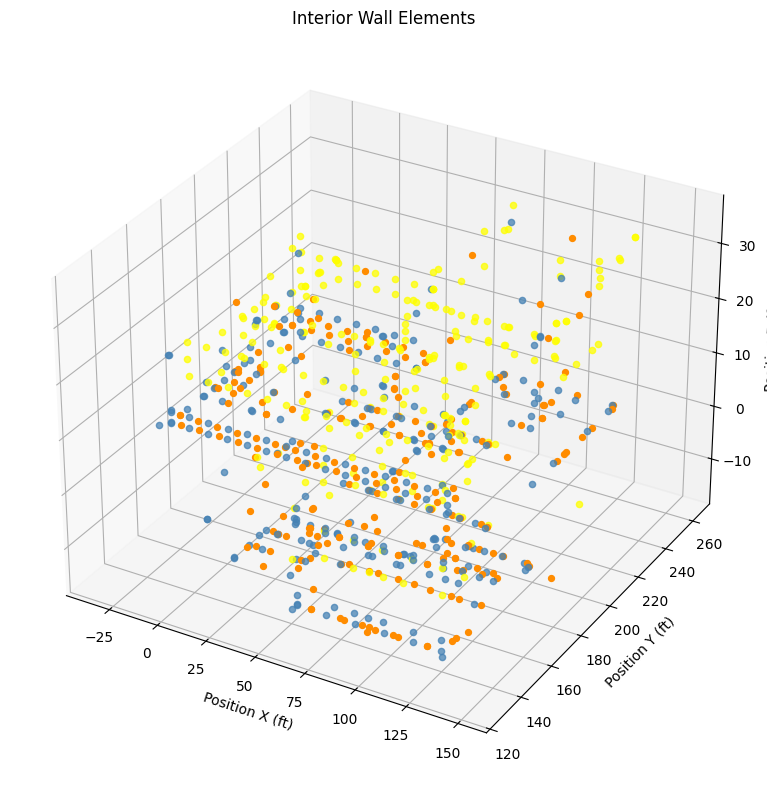

In [9]:
# Make a 3D plot of interior wall positions and bounding-box diagonals.
import matplotlib.pyplot as plt
import pandas as pd

coord_columns = [
    "Position X (ft)",
    "Position Y (ft)",
    "Position Z (ft)",
    "Bounding Box Min X (ft)",
    "Bounding Box Min Y (ft)",
    "Bounding Box Min Z (ft)",
    "Bounding Box Max X (ft)",
    "Bounding Box Max Y (ft)",
    "Bounding Box Max Z (ft)",
]

interior_walls = df[df["Category"].astype(str).eq("Walls")].copy()
interior_walls = interior_walls[
    ~interior_walls["Type"].astype(str).str.contains("Retaining", case=False, na=False)
]

for column in coord_columns:
    interior_walls[column] = pd.to_numeric(interior_walls[column], errors="coerce")

interior_walls = interior_walls.dropna(subset=coord_columns)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for _, row in interior_walls.iterrows():
    ax.scatter(
        row["Bounding Box Min X (ft)"],
        row["Bounding Box Min Y (ft)"], 
        row["Bounding Box Min Z (ft)"], 
        color="steelblue",
        alpha=0.75,
    )
    ax.scatter(
        row["Position X (ft)"],
        row["Position Y (ft)"],
        row["Position Z (ft)"],
        color="darkorange",
        s=18,
    )
    ax.scatter(
        row["Bounding Box Max X (ft)"],
        row["Bounding Box Max Y (ft)"],
        row["Bounding Box Max Z (ft)"],
        color="yellow",
        alpha=0.75,
    )

ax.set_title("Interior Wall Elements")
ax.set_xlabel("Position X (ft)")
ax.set_ylabel("Position Y (ft)")
ax.set_zlabel("Position Z (ft)")
plt.tight_layout()
plt.show()

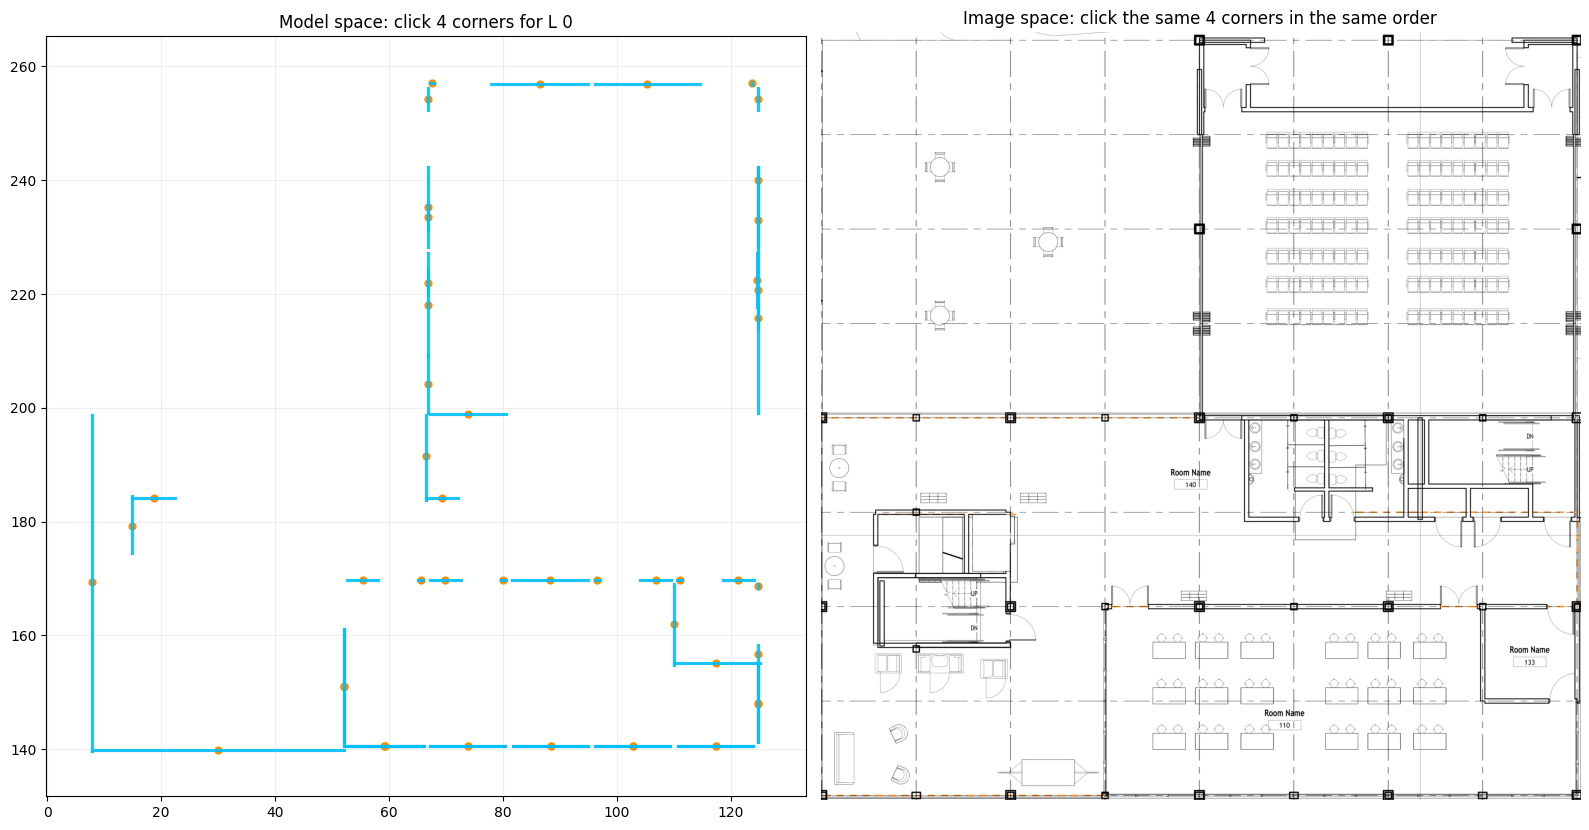

Click 4 building corners on the LEFT plot first, then press Enter.


C:\Users\ashmi\AppData\Local\Temp\ipykernel_65372\2414133503.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  model_clicks = np.array(plt.ginput(4, timeout=-1))


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [19]:
# Calibrate a model-to-image transform by clicking the same 4 corners in both views.
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

BACKGROUND_BY_LEVEL = {
    "L -1": Path("../floor_plans/cropped_png/04_Island_ARCH_ConceptB_Level -1_Mar6_page_0_cropped.png"),
    "L 0": Path("../floor_plans/cropped_png/04_Island_ARCH_ConceptB_Level 0_Mar6 (1)_page_0_cropped.png"),
    "L 1": Path("../floor_plans/cropped_png/04_Island_ARCH_ConceptB_Level 1_Mar6_page_0_cropped.png"),
}

df = pd.read_csv(r"C:\Ashmitha\Stanford\Quarter 2\PBL\IPD Challenge\revit_schedules\Arch\04_Island_ARCH_Concept2_V24_2026-04-23_04-35-08pm_detached_Architecture_TakeOff.csv")

level = "L 0"
walls_2d = interior_walls[interior_walls["Level"].astype(str).eq(level)].copy()
if walls_2d.empty:
    raise ValueError(f"No interior walls found for {level}.")

image_path = BACKGROUND_BY_LEVEL[level]
if not image_path.exists():
    raise FileNotFoundError(f"Missing cropped image: {image_path}")

image = mpimg.imread(image_path)

def wall_centerline(row):
    span_x = row["Bounding Box Max X (ft)"] - row["Bounding Box Min X (ft)"]
    span_y = row["Bounding Box Max Y (ft)"] - row["Bounding Box Min Y (ft)"]
    if span_x >= span_y:
        return np.array([
            [row["Bounding Box Min X (ft)"], row["Position Y (ft)"]],
            [row["Bounding Box Max X (ft)"], row["Position Y (ft)"]],
        ])
    return np.array([
        [row["Position X (ft)"], row["Bounding Box Min Y (ft)"]],
        [row["Position X (ft)"], row["Bounding Box Max Y (ft)"]],
    ])

all_points = np.vstack([wall_centerline(row) for _, row in walls_2d.iterrows()])
padding = 8.0
model_bounds = {
    "min_x": all_points[:, 0].min() - padding,
    "max_x": all_points[:, 0].max() + padding,
    "min_y": all_points[:, 1].min() - padding,
    "max_y": all_points[:, 1].max() + padding,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
model_ax, image_ax = axes

for _, row in walls_2d.iterrows():
    centerline = wall_centerline(row)
    model_ax.plot(centerline[:, 0], centerline[:, 1], color="deepskyblue", linewidth=2.25, alpha=0.9)
    model_ax.scatter(row["Position X (ft)"], row["Position Y (ft)"], color="darkorange", s=24)

model_ax.set_title(f"Model space: click 4 corners for {level}")
model_ax.set_xlim(model_bounds["min_x"], model_bounds["max_x"])
model_ax.set_ylim(model_bounds["min_y"], model_bounds["max_y"])
model_ax.set_aspect("equal")
model_ax.grid(alpha=0.2)

image_ax.imshow(image)
image_ax.set_title(f"Image space: click the same 4 corners in the same order")
image_ax.axis("off")

plt.tight_layout()
plt.show(block=False)

print("Click 4 building corners on the LEFT plot first, then press Enter.")
model_clicks = np.array(plt.ginput(4, timeout=-1))
if len(model_clicks) != 4:
    plt.close(fig)
    raise ValueError("Expected 4 model-space clicks.")

model_ax.scatter(model_clicks[:, 0], model_clicks[:, 1], color="crimson", s=70, marker="x")
fig.canvas.draw_idle()

print("Click the same 4 building corners on the RIGHT image in the same order, then press Enter.")
image_clicks = np.array(plt.ginput(4, timeout=-1))
if len(image_clicks) != 4:
    plt.close(fig)
    raise ValueError("Expected 4 image-space clicks.")

image_ax.scatter(image_clicks[:, 0], image_clicks[:, 1], color="crimson", s=70, marker="x")
fig.canvas.draw_idle()
plt.close(fig)

design = np.column_stack([model_clicks, np.ones(len(model_clicks))])
affine_x, *_ = np.linalg.lstsq(design, image_clicks[:, 0], rcond=None)
affine_y, *_ = np.linalg.lstsq(design, image_clicks[:, 1], rcond=None)
affine = np.vstack([affine_x, affine_y])

def transform_points(points):
    homogeneous = np.column_stack([points, np.ones(len(points))])
    return homogeneous @ affine.T

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image)

for _, row in walls_2d.iterrows():
    centerline = wall_centerline(row)
    transformed_line = transform_points(centerline)
    transformed_center = transform_points(np.array([[row["Position X (ft)"], row["Position Y (ft)"]]]))[0]
    ax.plot(transformed_line[:, 0], transformed_line[:, 1], color="deepskyblue", linewidth=2.25, alpha=0.9)
    ax.scatter(transformed_center[0], transformed_center[1], color="darkorange", s=24, edgecolors="white", linewidth=0.5)

ax.set_title(f"Calibrated interior wall overlay for {level}")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Remove the "CF" from the "Volume" column and convert it to numeric
df["Volume"] = df["Volume"].str.replace("CF", "").astype(float)
column_vol = df[df["Family"] == "Timber-Column"]["Volume"].sum()

In [6]:
DENSITY = 686 # Laminated Bamboo kg/m³

# Convert cubic feet to cubic meters
column_vol_m3 = column_vol * 0.0283168
# Calculate the mass in kg
column_mass_kg = column_vol_m3 * DENSITY
print(f"Total volume of Timber-Column: {column_vol} CF")
print(f"Total mass of Timber-Column: {column_mass_kg:.2f} kg")

Total volume of Timber-Column: 1760.9200000000005 CF
Total mass of Timber-Column: 34206.44 kg


In [9]:
df = pd.read_csv("../revit_schedules/MEP_TakeOff.csv")

In [ ]:
# [ 'Electrical Fixtures', 'Electrical Equipment',
#  'Mechanical Equipment',                'Ducts',        'Duct Fittings',
#            'Flex Ducts']

df["Family_Type"] = df["Family"] + " : " + df['Category']
df["Family_Type"].unique()

C:\Users\ashmi\AppData\Local\Temp\ipykernel_12836\4197666515.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df["Family_Type"][df["Family_Type"].isna()] = df["Category"][df["Family_Type"].isna()]


<ArrowStringArray>
[                                                  'Supply Diffuser : Air Terminals',
                                                     'Exhaust Grill : Air Terminals',
 'PRICE-40FF- Filter Frame Stamped Residential Grille-RETURN Hosted : Air Terminals',
                                                       '34274 : Electrical Fixtures',
                                                   'Return Diffuser : Air Terminals',
                                        'Utility Switchboard : Electrical Equipment',
                                   'Outdoor AHU - Horizontal : Mechanical Equipment',
                                                                                 nan,
                                       'Rectangular Elbow - Mitered : Duct Fittings',
                                                   'Rectangular Tee : Duct Fittings',
                                                 'Rectangular Cross : Duct Fittings',
                                   

In [47]:
df[df["Category"] == "Ducts"][["Type", "Parameter Snapshot"]].value_counts()

Type                   Parameter Snapshot                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
Mitered Elbows / Tees  Additional Flow=0 m³/h | Area=5 SF | Flow=25 m³/h | Free Size=24 1/4"x12 1/4" | Height=12" | Hydraulic Diameter=16" | Insulation Thickness=0" | Length=0' - 9" | Lining Thickness=0" | Lower End Bottom of Insulation Elevation=8' - 5 7/8" | Lower End Top of Insulation Elevation=9' - 6 1/8" | Overall Size=24 1/4"x12 1/4" | Pressure Drop=0.00 in-wg | Size=24"x12" | Size Lock=False | Upper End Bottom of Insulation Elevation=8'

In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

try:
    import fitz  # PyMuPDF
except ImportError as exc:
    raise ImportError(
        "This cell needs PyMuPDF. Install it with `pip install pymupdf pillow`."
    ) from exc

FLOOR_PLAN_DIR = Path("../floor_plans")
CROPPED_DIR = FLOOR_PLAN_DIR / "cropped_png"
CROPPED_DIR.mkdir(parents=True, exist_ok=True)

pdf_paths = sorted(FLOOR_PLAN_DIR.glob("*.pdf"))
if not pdf_paths:
    raise FileNotFoundError(f"No PDFs found in {FLOOR_PLAN_DIR.resolve()}")

print("Available floor plans:")
for idx, pdf_path in enumerate(pdf_paths):
    print(f"  [{idx}] {pdf_path.name}")

selection = input("Enter the PDF index to crop [0]: ").strip()
pdf_index = int(selection) if selection else 0
pdf_path = pdf_paths[pdf_index]

page_selection = input("Enter the page number to load [0]: ").strip()
page_index = int(page_selection) if page_selection else 0
zoom_selection = input("Enter render zoom for the preview [2.0]: ").strip()
zoom = float(zoom_selection) if zoom_selection else 2.0

doc = fitz.open(pdf_path)
page = doc.load_page(page_index)
pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), alpha=False)
image = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
image_np = np.array(image)
doc.close()

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(image_np)
ax.set_title(
    "Click 2 opposite grid-extents corners: top-left first, bottom-right second",
    fontsize=12,
)
ax.axis("on")
plt.tight_layout()
points = plt.ginput(2, timeout=-1)
plt.close(fig)

if len(points) != 2:
    raise ValueError("Expected exactly 2 clicks: top-left and bottom-right corners.")

(x1, y1), (x2, y2) = points
left = int(round(min(x1, x2)))
right = int(round(max(x1, x2)))
top = int(round(min(y1, y2)))
bottom = int(round(max(y1, y2)))

cropped = image.crop((left, top, right, bottom))
png_path = CROPPED_DIR / f"{pdf_path.stem}_page_{page_index}_cropped.png"
json_path = CROPPED_DIR / f"{pdf_path.stem}_page_{page_index}_crop_points.json"
cropped.save(png_path)

json_path.write_text(
    json.dumps(
        {
            "pdf": str(pdf_path.resolve()),
            "page_index": page_index,
            "zoom": zoom,
            "clicked_points": [
                {"x": round(x1, 2), "y": round(y1, 2)},
                {"x": round(x2, 2), "y": round(y2, 2)},
            ],
            "crop_box": {
                "left": left,
                "top": top,
                "right": right,
                "bottom": bottom,
            },
            "png": str(png_path.resolve()),
        },
        indent=2,
    ),
    encoding="utf-8",
)

print(f"Saved cropped PNG to: {png_path.resolve()}")
print(f"Saved crop metadata to: {json_path.resolve()}")

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(np.array(cropped))
ax.set_title(f"Cropped floor plan: {pdf_path.name}")
ax.axis("off")
plt.show()


Available floor plans:
  [0] 04_Island_ARCH_ConceptB_Level -1_Mar6.pdf
  [1] 04_Island_ARCH_ConceptB_Level 0_Mar6 (1).pdf
  [2] 04_Island_ARCH_ConceptB_Level 1_Mar6.pdf


In [22]:
df_micro_schedule = pd.read_csv("./Planning_engine/Micro_Schedule.csv")

In [23]:
df_schedule = pd.read_csv("./Planning_engine/Fuzor_Schedule_Template.csv")

In [24]:
df_schedule

,Task ID,Task Name,WBS Outline,At Completion Duration (Workhours),Predecessors,Start Date,End Date,Labor Hours Budgeted,Crew: Commissioning / Controls Support,Crew: Concrete Crew,...,Equipment: Compactor/Roller,Equipment: Concrete Pump,Equipment: Excavator,Equipment: Mobile Crane,Cost: Total Direct,Cost: Hourly Crew,Cost: Hourly Equipment,Cost: Labor,Cost: Equipment,Cost: Material
0,A1070,Install Construction Fencing,1.1.1,24.0,NaN,2029-10-01,2029-10-03,96.0,NaN,NaN,...,NaN,NaN,NaN,NaN,5760.0,240.0,0.0,5760.0,0.0,0.0
1,A1090,Temporary Water Installation,1.1.2,24.0,A1070,2029-10-04,2029-10-08,96.0,NaN,NaN,...,NaN,NaN,NaN,NaN,5760.0,240.0,0.0,5760.0,0.0,0.0
2,A1080,Install Site Office & Welfare Units,1.1.3,32.0,A1070,2029-10-04,2029-10-09,128.0,NaN,NaN,...,NaN,NaN,NaN,NaN,7680.0,240.0,0.0,7680.0,0.0,0.0
3,A1100,Temporary Power Installation,1.1.4,32.0,A1070,2029-10-04,2029-10-09,128.0,NaN,NaN,...,NaN,NaN,NaN,NaN,7680.0,240.0,0.0,7680.0,0.0,0.0
4,A1110,Tree Removal & Clearing,1.1.5,40.0,A1070,2029-10-04,2029-10-10,120.0,NaN,NaN,...,NaN,NaN,NaN,NaN,9600.0,240.0,0.0,9600.0,0.0,0.0
5,A1120,Bleacher Demolition,1.1.6,56.0,A1070,2029-10-04,2029-10-12,224.0,NaN,NaN,...,NaN,NaN,NaN,NaN,17920.0,320.0,0.0,17920.0,0.0,0.0
6,A1150,Laydown Area Preparation,1.1.7,0.0,A1110,2029-10-11,2029-10-11,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,240.0,0.0,0.0,0.0,0.0
7,A1140,Crane Pad Construction,1.1.8,40.0,A1110,2029-10-11,2029-10-17,160.0,NaN,NaN,...,NaN,NaN,NaN,NaN,9600.0,240.0,0.0,9600.0,0.0,0.0
8,A1170,Full Basement Excavation,1.2.1,56.0,NaN,2029-10-01,2029-10-09,168.0,NaN,NaN,...,NaN,NaN,1.0,NaN,20160.0,360.0,0.0,20160.0,0.0,0.0
9,A1190,Subgrade Preparation,1.2.2,32.0,A1170,2029-10-10,2029-10-15,96.0,NaN,NaN,...,1.0,NaN,NaN,NaN,11520.0,360.0,0.0,11520.0,0.0,0.0
